In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/creditcard.csv")

# Show the shape
print("Dataset shape:", df.shape)

# Show the first 5 rows
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Series([], dtype: int64)


In [3]:
# Count normal and fraudulent transactions
class_counts = df["Class"].value_counts()

print("Transaction counts:")
print(class_counts)

print("\nFraud percentage:")
print(df["Class"].mean() * 100)

Transaction counts:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage:
0.1727485630620034


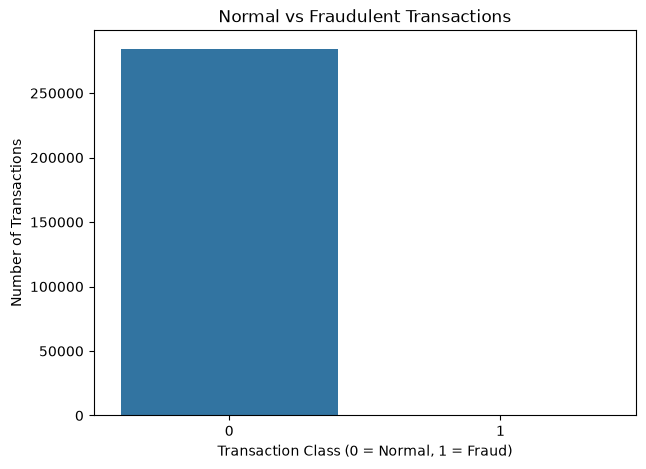

In [4]:
# Visualize normal vs fraudulent transactions

plt.figure(figsize=(7, 5))

sns.countplot(x="Class", data=df)

plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Transaction Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()


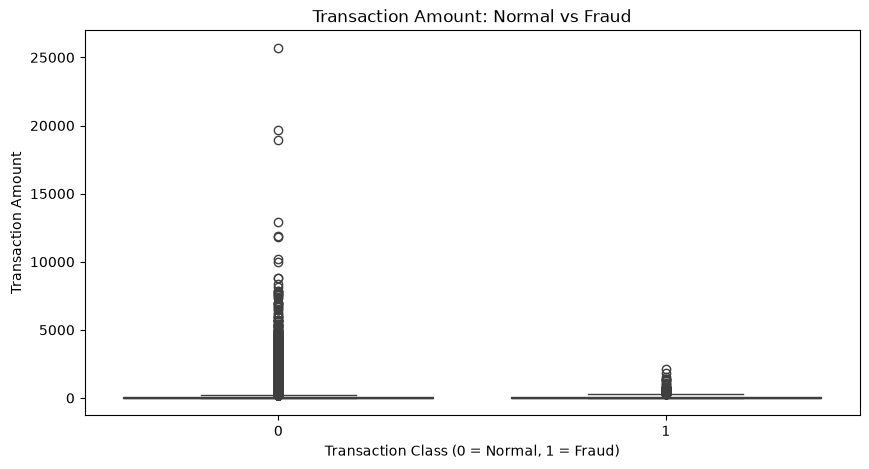

In [5]:
# Compare transaction amounts for normal and fraudulent transactions

plt.figure(figsize=(10, 5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount: Normal vs Fraud")
plt.xlabel("Transaction Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

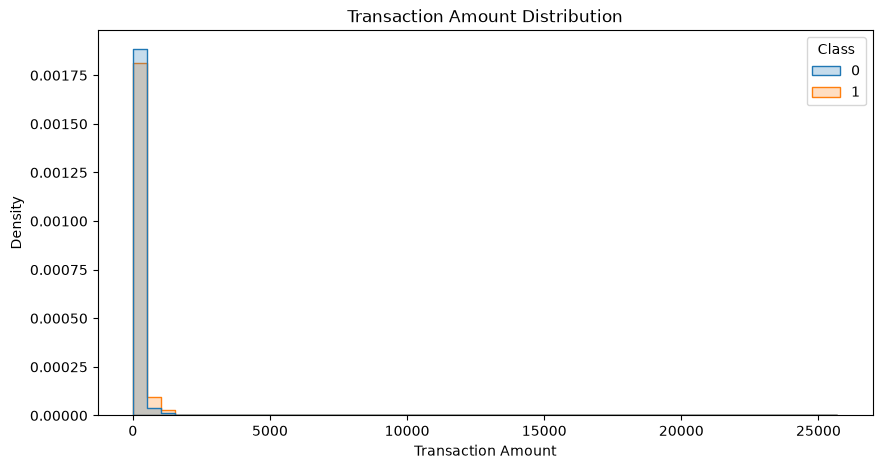

In [6]:
# Compare the distribution of transaction amounts

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")

plt.show()


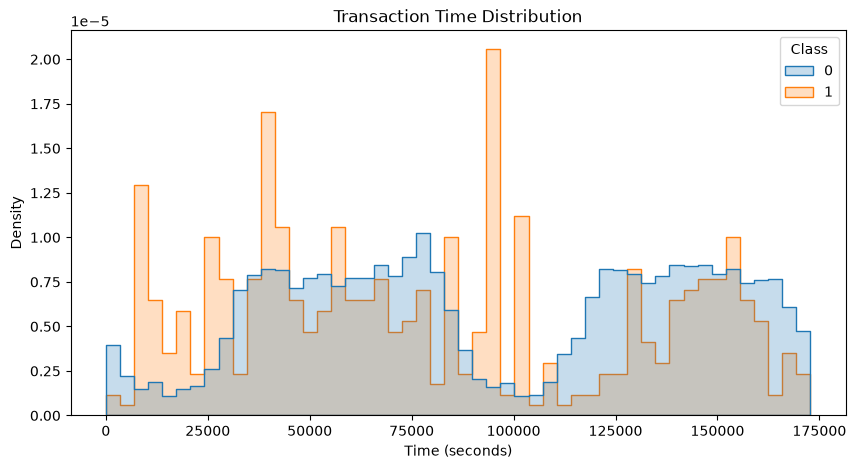

In [7]:
# Compare transaction time for normal and fraudulent transactions

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Density")

plt.show()

In [8]:
# Calculate correlations with the fraud target
correlations = df.corr(numeric_only=True)["Class"].sort_values()

print("Features most negatively correlated with fraud:")
print(correlations.head(5))

print("\nFeatures most positively correlated with fraud:")
print(correlations.tail(5))

Features most negatively correlated with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Features most positively correlated with fraud:
V21      0.040413
V2       0.091289
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64


In [9]:
# Separate input features from the target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Fraud cases:", y.sum())

Features shape: (284807, 30)
Target shape: (284807,)
Fraud cases: 492


In [10]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nFraud cases in training:", y_train.sum())
print("Fraud cases in testing:", y_test.sum())

Training set: (227845, 30)
Testing set: (56962, 30)

Fraud cases in training: 394
Fraud cases in testing: 98


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

# Create the model
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("PR-AUC:", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962

PR-AUC: 0.7357304956985353

Confusion Matrix:
[[55190  1674]
 [    8    90]]


/Users/nika/Desktop/untitled folder/credit-card-fraud-detection/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

print("Random Forest PR-AUC:", average_precision_score(y_test, rf_prob))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.79      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Random Forest PR-AUC: 0.8625957736649601

Random Forest Confusion Matrix:
[[56857     7]
 [   21    77]]


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics for Logistic Regression
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)
lr_pr_auc = average_precision_score(y_test, y_prob)

# Calculate metrics for Random Forest
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_pr_auc = average_precision_score(y_test, rf_prob)

print("MODEL COMPARISON")
print("=" * 50)

print("\nLogistic Regression")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"PR-AUC:    {lr_pr_auc:.4f}")

print("\nRandom Forest")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"PR-AUC:    {rf_pr_auc:.4f}")

MODEL COMPARISON

Logistic Regression
Precision: 0.0510
Recall:    0.9184
F1-Score:  0.0967
PR-AUC:    0.7357

Random Forest
Precision: 0.9167
Recall:    0.7857
F1-Score:  0.8462
PR-AUC:    0.8626


In [14]:
import pandas as pd
df = pd.read_csv("../data/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Balance only the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training set:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nNew training shape:", X_train_smote.shape)

Original training set:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

New training shape: (454902, 30)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score

# If train/test split was lost (kernel restart), recreate it here
try:
    X_train
    X_test
    y_train
    y_test
except NameError:
    import pandas as pd
    df = pd.read_csv("../data/creditcard.csv")
    X = df.drop("Class", axis=1)
    y = df["Class"]
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("Recreated train/test split inside LR cell.")

# If SMOTE-resampled variables are missing, run SMOTE now
try:
    X_train_smote
    y_train_smote
except NameError:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print("SMOTE executed inside LR cell. New training shape:", X_train_smote.shape)

# Train Logistic Regression on SMOTE-balanced data
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_smote.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_lr_smote = lr_smote.predict(X_test)
y_prob_lr_smote = lr_smote.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression + SMOTE")
print(classification_report(y_test, y_pred_lr_smote))

print("PR-AUC:", average_precision_score(y_test, y_prob_lr_smote))

Logistic Regression + SMOTE
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962

PR-AUC: 0.7240299031948415


/Users/nika/Desktop/untitled folder/credit-card-fraud-detection/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score

# Train Random Forest on SMOTE-balanced training data
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf_smote = rf_smote.predict(X_test)
y_prob_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest + SMOTE")
print(classification_report(y_test, y_pred_rf_smote))

print("PR-AUC:", average_precision_score(y_test, y_prob_rf_smote))

Random Forest + SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC: 0.8743026321535916


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Rebuild required data if the notebook was restarted or cells were run out of order
try:
    X_train
    X_test
    y_train
    y_test
except NameError:
    import pandas as pd
    df = pd.read_csv("../data/creditcard.csv")
    X = df.drop("Class", axis=1)
    y = df["Class"]
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

try:
    X_train_smote
    y_train_smote
except NameError:
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

try:
    y_pred_lr_smote
    y_prob_lr_smote
except NameError:
    lr_smote = LogisticRegression(max_iter=1000, random_state=42)
    lr_smote.fit(X_train_smote, y_train_smote)
    y_pred_lr_smote = lr_smote.predict(X_test)
    y_prob_lr_smote = lr_smote.predict_proba(X_test)[:, 1]

try:
    y_pred_rf_smote
    y_prob_rf_smote
except NameError:
    rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_smote.fit(X_train_smote, y_train_smote)
    y_pred_rf_smote = rf_smote.predict(X_test)
    y_prob_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

# Logistic Regression + SMOTE
lr_precision = precision_score(y_test, y_pred_lr_smote)
lr_recall = recall_score(y_test, y_pred_lr_smote)
lr_f1 = f1_score(y_test, y_pred_lr_smote)
lr_pr_auc = average_precision_score(y_test, y_prob_lr_smote)

# Random Forest + SMOTE
rf_precision = precision_score(y_test, y_pred_rf_smote)
rf_recall = recall_score(y_test, y_pred_rf_smote)
rf_f1 = f1_score(y_test, y_pred_rf_smote)
rf_pr_auc = average_precision_score(y_test, y_prob_rf_smote)

print("MODEL COMPARISON")
print("=" * 55)

print("\nLogistic Regression + SMOTE")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"PR-AUC:    {lr_pr_auc:.4f}")

print("\nRandom Forest + SMOTE")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"PR-AUC:    {rf_pr_auc:.4f}")

MODEL COMPARISON

Logistic Regression + SMOTE
Precision: 0.1270
Recall:    0.8980
F1-Score:  0.2225
PR-AUC:    0.7240

Random Forest + SMOTE
Precision: 0.8265
Recall:    0.8265
F1-Score:  0.8265
PR-AUC:    0.8743


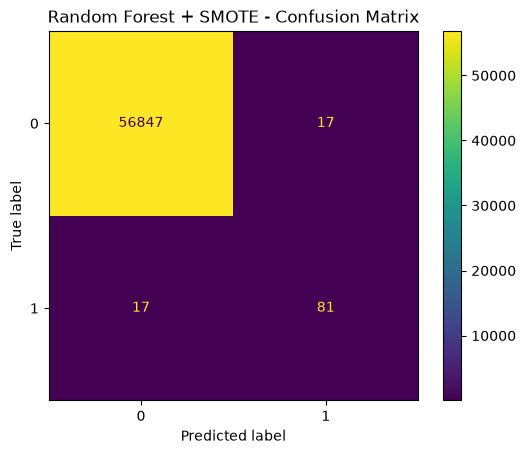

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Display confusion matrix for Random Forest + SMOTE
try:
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_rf_smote,
    )
except NameError:
    # If variables are missing (kernel restarted or cells ran out of order),
    # rebuild the minimal state and re-run the prediction pipeline.
    import pandas as pd
    df = pd.read_csv("../data/creditcard.csv")
    X = df.drop("Class", axis=1)
    y = df["Class"]
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
    try:
        y_pred_rf_smote
    except NameError:
        from imblearn.over_sampling import SMOTE
        from sklearn.ensemble import RandomForestClassifier
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
        rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf_smote.fit(X_train_smote, y_train_smote)
        y_pred_rf_smote = rf_smote.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_smote)

plt.title("Random Forest + SMOTE - Confusion Matrix")
plt.show()

In [20]:
# Get feature importance from the Random Forest

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_smote.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

Top 10 Most Important Features:
   Feature  Importance
14     V14    0.217114
10     V10    0.119687
4       V4    0.117376
12     V12    0.107649
17     V17    0.086365
3       V3    0.070819
11     V11    0.049883
16     V16    0.040005
2       V2    0.038819
9       V9    0.028301


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

accuracy = accuracy_score(y_test, y_pred_rf_smote)
precision = precision_score(y_test, y_pred_rf_smote)
recall = recall_score(y_test, y_pred_rf_smote)
f1 = f1_score(y_test, y_pred_rf_smote)
pr_auc = average_precision_score(y_test, y_prob_rf_smote)

print("FINAL MODEL PERFORMANCE")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

FINAL MODEL PERFORMANCE
Accuracy:  0.9994
Precision: 0.8265
Recall:    0.8265
F1-Score:  0.8265
PR-AUC:    0.8743


In [22]:
import joblib
from pathlib import Path

# Create models folder if it doesn't exist
Path("../models").mkdir(exist_ok=True)

# Save the Random Forest model
joblib.dump(rf_smote, "../models/random_forest_smote.pkl")

# Save the feature names
joblib.dump(list(X_train.columns), "../models/feature_names.pkl")

print("Model saved successfully!")
print("Location: models/random_forest_smote.pkl")

Model saved successfully!
Location: models/random_forest_smote.pkl
